# Ejemplo de Aprendizaje Supervisado - Clasificación usando NaiveBayes

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de la creación de un modelo predictivo para una variable discreta usando `GaussianNB`

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_abandono_estudiantes.csv

--2026-06-03 23:05:32--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_abandono_estudiantes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 67325 (66K) [text/plain]
Saving to: ‘data_abandono_estudiantes.csv’

data_abandono_estud 100%[===================>]  65.75K  --.-KB/s    in 0.01s   

2026-06-03 23:05:33 (4.95 MB/s) - ‘data_abandono_estudiantes.csv’ saved [67325/67325]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB

from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [ ]:
data = pd.read_csv("data_abandono_estudiantes.csv")
data.head()

,asistencia,tareas,promedio,abandono
0,50.504750,4.025754,1.413109,1
1,73.937271,7.181062,5.296829,0
2,99.866453,7.576778,5.723104,0
3,45.533813,4.982729,4.453586,1
4,66.542790,8.324001,4.099583,0


In [ ]:
data.dtypes

,0
asistencia,float64
tareas,float64
promedio,float64
abandono,int64


In [ ]:
target = "abandono"

In [ ]:
data[target].value_counts()

,count
abandono,
0,855
1,345


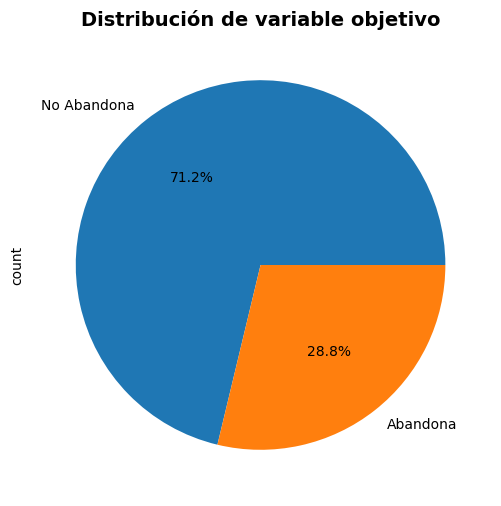

In [ ]:
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No Abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,abandono
abandono,1.000000
promedio,-0.756731
tareas,-0.790920
asistencia,-0.816212


In [ ]:
X = data.drop(target, axis=1)
y = data[target]

In [ ]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [ ]:
features_num = X.select_dtypes(include="number").columns
features_cat = X.select_dtypes(exclude="number").columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=29,
                                                    stratify=y)

In [ ]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division = 0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

# Modelo línea base

In [ ]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_nb = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", GaussianNB())
])

In [ ]:
# Evaluación
metricas_nb = evaluar(pipeline_modelo_nb, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_nb['accuracy']:.4f}")
print(f"{'F1 Score':<20}: {metricas_nb['f1']:.4f}")
print(f"{'Precision':<20}: {metricas_nb['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_nb['recall']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_nb['roc_auc']:.4f}")

Accuracy            : 0.9792
F1 Score            : 0.9630
Precision           : 0.9848
Recall              : 0.9420
ROC AUC Score       : 0.9889


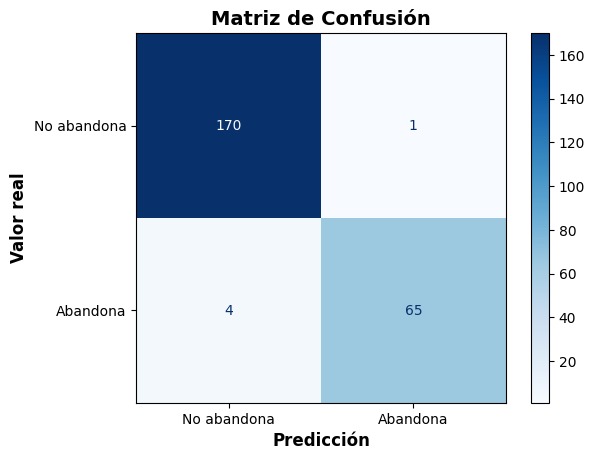

In [ ]:
y_pred = pipeline_modelo_nb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No abandona", "Abandona"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_nb.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_nb.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99167
Score del modelo en test                :0.97917


In [ ]:
y_pred_probabilidades = pipeline_modelo_nb.predict_proba(X_test)[:,1]
y_pred_probabilidades[:5]

array([9.99999932e-01, 1.05776417e-04, 1.74262998e-04, 9.99999988e-01,
       2.31232839e-06])

In [ ]:
y_pred[:5]

array([1, 0, 0, 1, 0])

# Mejora del modelo

Para `GaussianNB`, el hiperparámetro más importante es `var_smoothing`

Este parámetro agrega una pequeña cantidad a la varianza para evitar problemas numéricos.

In [ ]:
param_grid = {
    'modelo__var_smoothing': np.logspace(-12, -3, 50)
}

In [ ]:
grid = GridSearchCV(
    estimator=pipeline_modelo_nb,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring='f1',
    n_jobs=-1
)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         Index(['asistencia', 'tareas', 'promed...
       2.55954792e-08, 3.90693994e-08, 5.96362332e-08, 9.10298178e-08,
       1.38949549e-07, 2.12095089e-07, 3.23745754e-07, 4.94171336e-07,
       7.54312006e-07, 1.15139540e-06, 1.75751062e-06, 2.68269580e-06,
       4.09491506e-06, 6.25055193e-06, 9.54095476e-06, 1.45634848e-05,
       2.22299648e-05, 3.39322177e-05, 5.17947468e-05, 7.90604321e-05,
       1.20679264e-04, 1.84206997e-04, 2.81176870e-04, 4.29193426e-04,
       6.55128557e-04, 1.00000000e-03])},
             scoring='f1')

In [ ]:
print("Mejores parámetros:")
print(grid.best_params_)

Mejores parámetros:
{'modelo__var_smoothing': np.float64(1e-12)}


In [ ]:
best_model_nb = grid.best_estimator_

In [ ]:
# Evaluación
metricas_nb_mejor = evaluar(best_model_nb, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_nb_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_nb_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_nb_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_nb_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_nb_mejor['recall']:.4f}")

Accuracy            : 0.9792
F1 Score:           : 0.9630
ROC AUC Score       : 0.9889
Precision           : 0.9848
Recall              : 0.9420


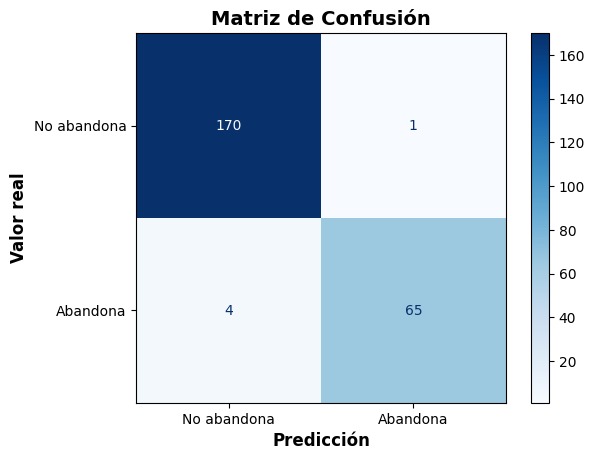

In [ ]:
y_pred = best_model_nb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No abandona", "Abandona"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [ ]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_nb.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_nb.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99167
Score del modelo en test                :0.97917


In [ ]:
print(f"Mejor F1 promedio: {grid.best_score_.round(4)}")

Mejor F1 promedio: 0.9873


In [ ]:
resultados = pd.DataFrame(grid.cv_results_)

resultados[
    [
        'param_modelo__var_smoothing',
        'mean_test_score',
        'std_test_score'
    ]
].sort_values(
    by='mean_test_score',
    ascending=False
)

,param_modelo__var_smoothing,mean_test_score,std_test_score
0,1.000000e-12,0.98732,0.009326
1,1.526418e-12,0.98732,0.009326
2,2.329952e-12,0.98732,0.009326
3,3.556480e-12,0.98732,0.009326
4,5.428675e-12,0.98732,0.009326
5,8.286428e-12,0.98732,0.009326
6,1.264855e-11,0.98732,0.009326
7,1.930698e-11,0.98732,0.009326
8,2.947052e-11,0.98732,0.009326
9,4.498433e-11,0.98732,0.009326


# Independencia condicional

In [ ]:
data.columns

Index(['asistencia', 'tareas', 'promedio', 'abandono'], dtype='object')

In [ ]:
features_num

Index(['asistencia', 'tareas', 'promedio'], dtype='object')

In [ ]:
corr = data[features_num].corr()

print(corr.round(2))

            asistencia  tareas  promedio
asistencia        1.00    0.65      0.62
tareas            0.65    1.00      0.61
promedio          0.62    0.61      1.00


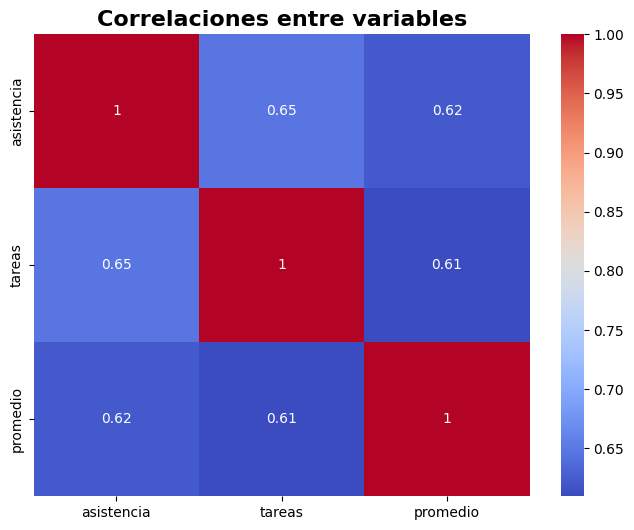

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlaciones entre variables", fontsize=16, fontweight="bold")
plt.show()

| Correlación | Interpretación aproximada |
| ----------- | ------------------------- |
| 0.00 - 0.10 | Prácticamente nula        |
| 0.10 - 0.30 | Débil                     |
| 0.30 - 0.50 | Moderada                  |
| > 0.50      | Fuerte                    |


Si dos variables son independientes, entonces su correlación será 0.

Sin embargo,  el recíproco no siempre es cierto:

Correlación cercana a 0 **NO** implica necesariamente independencia.

Por ejemplo, $y=x^2$

con X distribuida simétricamente alrededor de 0.

La correlación entre $x$ e $y$ puede ser cercana a 0, pero claramente existe dependencia.

# Magia!!!

In [ ]:
data[data["abandono"]==0].corr()

,asistencia,tareas,promedio,abandono
asistencia,1.000000,0.044880,-0.026207,NaN
tareas,0.044880,1.000000,-0.017126,NaN
promedio,-0.026207,-0.017126,1.000000,NaN
abandono,NaN,NaN,NaN,NaN


In [ ]:
data[data["abandono"]==1].corr()

,asistencia,tareas,promedio,abandono
asistencia,1.000000,-0.027052,0.060889,NaN
tareas,-0.027052,1.000000,0.067614,NaN
promedio,0.060889,0.067614,1.000000,NaN
abandono,NaN,NaN,NaN,NaN


La correlación observada en el conjunto completo aparece porque:

Clase ▶ Asistencia ▶ Tareas

No porque asistencia causara tareas.

La clase era la variable que explicaba gran parte de la relación.

Recordar ...

$P(X_1, X_2 |C)=P(X_1|C)*P(X_2|C)$

**Entonces ...**

Las variables predictoras presentan una dependencia importante cuando se analizan conjuntamente, pero esa dependencia disminuye considerablemente al condicionar por la clase. Esto sugiere que parte de la asociación observada entre las variables es explicada por la variable objetivo, lo que hace razonable el supuesto de independencia condicional utilizado por Naive Bayes.

**Relación con Naive Bayes**

Recordar que Naive Bayes NO supone:

$P(X_1, X_2)=P(X_1)*P(X_2)$

Eso sería independencia total.

Lo que supone es:

$P(X_1, X_2 |C)=P(X_1|C)*P(X_2|C)$

es decir:

*"Una vez conocida la clase, las variables se comportan aproximadamente como independientes."*

## Importante

No se debe concluir:

*"Las variables son independientes."*

Porque las correlaciones no son exactamente cero.

La conclusión académicamente correcta sería:

---

*"Los datos muestran evidencia compatible con la independencia condicional, ya que las asociaciones entre las variables disminuyen considerablemente al analizar cada clase por separado."*

----

# Cierre

Se observaron correlaciones superiores a 0.6 en el conjunto completo. Sin embargo, al separar los datos según la variable objetivo, estas correlaciones disminuyen notablemente.

Esto indica que gran parte de la dependencia observada estaba explicada por la clase. Por lo tanto, **el supuesto de independencia condicional utilizado por Naive Bayes parece razonable para este conjunto de datos.**